# 🧪 Investment Risk BI Platform — Test Pipeline Completo
### Jupyter Lab · Test end-to-end con dataset sintetico

Questo notebook testa tutta la pipeline in sequenza:
1. Setup database MySQL
2. Creazione CSV sintetico
3. `validator.py` — validazione e normalizzazione
4. `fetcher.py` — download prezzi da yfinance
5. `risk_engine.py` — calcolo metriche
6. `exporter.py` — generazione CSV per Looker Studio / Power BI

> ⚙️ **Prima di iniziare:** modifica la cella di configurazione con le tue credenziali MySQL.


## 0 · Installazione dipendenze

In [1]:
# Esegui questa cella solo la prima volta
import subprocess, sys

pkgs = [
    "yfinance", "sqlalchemy", "pymysql",
    "pandas", "numpy", "plotly", "streamlit"
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Dipendenze installate")


✅ Dipendenze installate


## 1 · Configurazione — modifica qui le tue credenziali

In [2]:
# ⚙️ MODIFICA QUESTI VALORI con le tue credenziali MySQL
DB_HOST     = "localhost"
DB_PORT     = 3306
DB_USER     = "root"
DB_PASSWORD = "root"   # <-- cambia qui
DB_NAME     = "investment_risk_bi"

PORTFOLIO_NAME = "Test Portfolio"

print(f"Config: {DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}")


Config: root@localhost:3306/investment_risk_bi


## 2 · Setup MySQL — crea database e tabelle

In [3]:
import sqlalchemy
from sqlalchemy import create_engine, text

# Connessione senza database (per crearlo)
engine_root = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}",
    echo=False
)

schema_sql = [
    f"CREATE DATABASE IF NOT EXISTS {DB_NAME} CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci",
    f"USE {DB_NAME}",
    """CREATE TABLE IF NOT EXISTS portfolios (
        portfolio_id  INT          NOT NULL AUTO_INCREMENT,
        name          VARCHAR(100) NOT NULL,
        owner         VARCHAR(100) NOT NULL DEFAULT 'anonymous',
        base_currency CHAR(3)      NOT NULL DEFAULT 'EUR',
        created_at    DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
        description   TEXT,
        PRIMARY KEY (portfolio_id)
    ) ENGINE=InnoDB""",
    """CREATE TABLE IF NOT EXISTS assets (
        asset_id    INT          NOT NULL AUTO_INCREMENT,
        ticker      VARCHAR(20)  NOT NULL,
        name        VARCHAR(200),
        asset_class ENUM('stock','etf','bond','crypto','cash') NOT NULL,
        currency    CHAR(3)      NOT NULL,
        gics_sector VARCHAR(100),
        country     VARCHAR(100),
        PRIMARY KEY (asset_id),
        UNIQUE KEY uq_ticker (ticker)
    ) ENGINE=InnoDB""",
    """CREATE TABLE IF NOT EXISTS transactions (
        tx_id        INT           NOT NULL AUTO_INCREMENT,
        portfolio_id INT           NOT NULL,
        asset_id     INT           NOT NULL,
        tx_date      DATE          NOT NULL,
        tx_type      ENUM('buy','sell','dividend') NOT NULL,
        quantity     DECIMAL(18,8) NOT NULL,
        price        DECIMAL(18,6) NOT NULL,
        currency     CHAR(3)       NOT NULL,
        fees         DECIMAL(10,4) NOT NULL DEFAULT 0.0000,
        notes        VARCHAR(255),
        PRIMARY KEY (tx_id),
        CONSTRAINT fk_tx_portfolio FOREIGN KEY (portfolio_id) REFERENCES portfolios(portfolio_id) ON DELETE CASCADE,
        CONSTRAINT fk_tx_asset     FOREIGN KEY (asset_id)     REFERENCES assets(asset_id)         ON DELETE RESTRICT,
        INDEX idx_tx_portfolio (portfolio_id),
        INDEX idx_tx_asset     (asset_id),
        INDEX idx_tx_date      (tx_date)
    ) ENGINE=InnoDB""",
    """CREATE TABLE IF NOT EXISTS market_prices (
        price_id   INT           NOT NULL AUTO_INCREMENT,
        asset_id   INT           NOT NULL,
        price_date DATE          NOT NULL,
        close      DECIMAL(18,6) NOT NULL,
        volume     BIGINT,
        source     VARCHAR(50)   NOT NULL DEFAULT 'yfinance',
        PRIMARY KEY (price_id),
        CONSTRAINT fk_prices_asset FOREIGN KEY (asset_id) REFERENCES assets(asset_id) ON DELETE CASCADE,
        UNIQUE KEY uq_asset_date (asset_id, price_date),
        INDEX idx_prices_date (price_date)
    ) ENGINE=InnoDB"""
]

with engine_root.connect() as conn:
    for stmt in schema_sql:
        conn.execute(text(stmt))
    conn.commit()

print(f"✅ Database '{DB_NAME}' e tabelle create correttamente")


✅ Database 'investment_risk_bi' e tabelle create correttamente


## 3 · Creazione CSV sintetico realistico

Il dataset contiene un portafoglio multi-asset con:
- **Azioni**: AAPL, MSFT
- **ETF**: VWRL.L (world ETF)  
- **Crypto**: BTC-USD
- **Bond**: simulato con ISIN fittizio
- **Casi edge**: dividendi, vendita parziale, ticker crypto senza coppia valuta


In [4]:
import pandas as pd
import os

# Dataset sintetico — portafoglio realistico 2021-2024
csv_data = """tx_date,ticker,tx_type,quantity,price,currency,fees,asset_class,notes
2021-01-15,AAPL,buy,10,128.98,USD,1.50,stock,Primo acquisto AAPL
2021-03-10,MSFT,buy,5,232.10,USD,1.50,stock,Acquisto MSFT
2021-06-01,VWRL.L,buy,20,88.50,GBP,0.00,etf,ETF world
2021-09-01,BTC,buy,0.1,47200.00,USD,5.00,crypto,Bitcoin senza coppia valuta
2021-11-15,AAPL,buy,5,150.50,USD,1.50,stock,Acquisto aggiuntivo
2022-01-20,MSFT,sell,2,295.00,USD,1.50,stock,Presa parziale profitto
2022-03-01,AAPL,dividend,0,0.22,USD,0.00,stock,Dividendo Q1 2022
2022-06-15,VWRL.L,buy,10,82.30,GBP,0.00,etf,Acquisto in calo
2022-09-01,AAPL,dividend,0,0.23,USD,0.00,stock,Dividendo Q3 2022
2022-11-01,BTC-USD,buy,0.05,20100.00,USD,3.00,crypto,DCA Bitcoin
2023-01-10,MSFT,buy,3,240.50,USD,1.50,stock,Riacquisto MSFT
2023-03-01,AAPL,dividend,1,2.30,USD,0.00,stock,Dividendo con quantity=1 edge case
2023-06-01,VWRL.L,sell,5,95.20,GBP,0.00,etf,Presa parziale profitto ETF
2023-09-15,AAPL,buy,8,178.90,USD,1.50,stock,Acquisto Q3
2024-01-05,MSFT,buy,2,374.00,USD,1.50,stock,Acquisto inizio anno
2024-03-01,AAPL,dividend,0,0.25,USD,0.00,stock,Dividendo Q1 2024
"""

os.makedirs("data", exist_ok=True)
with open("data/test_portfolio.csv", "w", encoding="utf-8") as f:
    f.write(csv_data)

df_preview = pd.read_csv("data/test_portfolio.csv")
print(f"✅ CSV creato: {len(df_preview)} righe")
print(f"   Ticker:     {sorted(df_preview['ticker'].unique().tolist())}")
print(f"   Tx types:   {df_preview['tx_type'].value_counts().to_dict()}")
print()
display(df_preview)


✅ CSV creato: 16 righe
   Ticker:     ['AAPL', 'BTC', 'BTC-USD', 'MSFT', 'VWRL.L']
   Tx types:   {'buy': 10, 'dividend': 4, 'sell': 2}



,tx_date,ticker,tx_type,quantity,price,currency,fees,asset_class,notes
0,2021-01-15,AAPL,buy,10.00,128.98,USD,1.5,stock,Primo acquisto AAPL
1,2021-03-10,MSFT,buy,5.00,232.10,USD,1.5,stock,Acquisto MSFT
2,2021-06-01,VWRL.L,buy,20.00,88.50,GBP,0.0,etf,ETF world
3,2021-09-01,BTC,buy,0.10,47200.00,USD,5.0,crypto,Bitcoin senza coppia valuta
4,2021-11-15,AAPL,buy,5.00,150.50,USD,1.5,stock,Acquisto aggiuntivo
5,2022-01-20,MSFT,sell,2.00,295.00,USD,1.5,stock,Presa parziale profitto
6,2022-03-01,AAPL,dividend,0.00,0.22,USD,0.0,stock,Dividendo Q1 2022
7,2022-06-15,VWRL.L,buy,10.00,82.30,GBP,0.0,etf,Acquisto in calo
8,2022-09-01,AAPL,dividend,0.00,0.23,USD,0.0,stock,Dividendo Q3 2022
9,2022-11-01,BTC-USD,buy,0.05,20100.00,USD,3.0,crypto,DCA Bitcoin


## 4 · Test `validator.py`

Verifica:
- ✅ Normalizzazione date
- ✅ Fix ticker crypto (BTC → BTC-USD)  
- ✅ Fix dividend con quantity=1
- ✅ Aggiunta colonne opzionali mancanti
- ✅ Report errori / warning / fix


In [5]:
import sys
sys.path.insert(0, ".")  # assicura che i moduli locali siano trovati

from validator import validate_csv, print_report

df_raw = pd.read_csv("data/test_portfolio.csv", dtype=str)

print("📋 DATI GREZZI:")
print(f"   Righe:   {len(df_raw)}")
print(f"   Colonne: {df_raw.columns.tolist()}")
print()

df_clean, report = validate_csv(df_raw)
print_report(report)

if df_clean is None:
    print("❌ VALIDAZIONE FALLITA — controlla gli errori sopra")
else:
    print("\n📊 DATI VALIDATI:")
    display(df_clean)
    print(f"\n📌 Tipi colonne:")
    print(df_clean.dtypes)


📋 DATI GREZZI:
   Righe:   16
   Colonne: ['tx_date', 'ticker', 'tx_type', 'quantity', 'price', 'currency', 'fees', 'asset_class', 'notes']


  VALIDATION REPORT

🟢 FIX APPLICATI (3):
   • Date normalizzate a formato YYYY-MM-DD
   • Ticker crypto corretti aggiungendo coppia valuta: ['BTC-USD']
   • 1 righe dividend con quantity=1 normalizzate a 0 (price interpretato come importo totale)

📊 STATISTICHE:
   Righe valide:  16
   Transazioni:   {'buy': 10, 'dividend': 4, 'sell': 2}
   Asset class:   {'stock': 11, 'etf': 3, 'crypto': 2}
   Ticker:        ['AAPL', 'BTC-USD', 'MSFT', 'VWRL.L']
   Valute:        ['GBP', 'USD']
   Intervallo:    2021-01-15 00:00:00  →  2024-03-01 00:00:00
   Valido:        ✅ SÌ


📊 DATI VALIDATI:


C:\Users\Alessandro Personale\Desktop\CAPSTONE PROJECT\validator.py:158: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["tx_date"] = pd.to_datetime(


,tx_date,ticker,tx_type,quantity,price,currency,fees,asset_class,notes
0,2021-01-15,AAPL,buy,10.00,128.98,USD,1.5,stock,Primo acquisto AAPL
1,2021-03-10,MSFT,buy,5.00,232.10,USD,1.5,stock,Acquisto MSFT
2,2021-06-01,VWRL.L,buy,20.00,88.50,GBP,0.0,etf,ETF world
3,2021-09-01,BTC-USD,buy,0.10,47200.00,USD,5.0,crypto,Bitcoin senza coppia valuta
4,2021-11-15,AAPL,buy,5.00,150.50,USD,1.5,stock,Acquisto aggiuntivo
5,2022-01-20,MSFT,sell,2.00,295.00,USD,1.5,stock,Presa parziale profitto
6,2022-03-01,AAPL,dividend,0.00,0.22,USD,0.0,stock,Dividendo Q1 2022
7,2022-06-15,VWRL.L,buy,10.00,82.30,GBP,0.0,etf,Acquisto in calo
8,2022-09-01,AAPL,dividend,0.00,0.23,USD,0.0,stock,Dividendo Q3 2022
9,2022-11-01,BTC-USD,buy,0.05,20100.00,USD,3.0,crypto,DCA Bitcoin



📌 Tipi colonne:
tx_date        datetime64[ns]
ticker                 object
tx_type                object
quantity              float64
price                 float64
currency               object
fees                  float64
asset_class            object
notes                  object
dtype: object


## 5 · Test `fetcher.py`

Scarica prezzi storici da yfinance e li scrive su MySQL.

> ⏱ **Tempo atteso**: 15-30 secondi (dipende dalla connessione internet)  
> 📡 Ticker testati: AAPL, MSFT, VWRL.L, BTC-USD  
> ⏭ ISIN: skippati automaticamente (prezzo da CSV)


In [6]:
from fetcher import fetch_and_store, get_engine
from sqlalchemy import text

# Connessione al database
engine = get_engine(DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, DB_NAME)

# Inserisce il portfolio nel DB
with engine.begin() as conn:
    conn.execute(text("""
        INSERT INTO portfolios (name, owner, base_currency)
        VALUES (:name, 'test_user', 'EUR')
    """), {"name": PORTFOLIO_NAME})
    portfolio_id = conn.execute(text("SELECT LAST_INSERT_ID()")).scalar()

print(f"✅ Portfolio creato con ID: {portfolio_id}")

# Inserisce le transazioni
with engine.begin() as conn:
    for _, row in df_clean.iterrows():
        # Upsert asset
        conn.execute(text("""
            INSERT INTO assets (ticker, name, asset_class, currency)
            VALUES (:ticker, :ticker, :asset_class, :currency)
            ON DUPLICATE KEY UPDATE ticker=ticker
        """), {
            "ticker":      row["ticker"],
            "asset_class": row["asset_class"] or "stock",
            "currency":    row["currency"],
        })
        asset_id = conn.execute(
            text("SELECT asset_id FROM assets WHERE ticker=:t"),
            {"t": row["ticker"]}
        ).scalar()

        conn.execute(text("""
            INSERT INTO transactions
                (portfolio_id, asset_id, tx_date, tx_type, quantity, price, currency, fees, notes)
            VALUES
                (:pid, :aid, :tx_date, :tx_type, :quantity, :price, :currency, :fees, :notes)
        """), {
            "pid":      portfolio_id,
            "aid":      asset_id,
            "tx_date":  str(row["tx_date"])[:10],
            "tx_type":  row["tx_type"],
            "quantity": float(row["quantity"]),
            "price":    float(row["price"]),
            "currency": row["currency"],
            "fees":     float(row["fees"]),
            "notes":    row.get("notes"),
        })

print(f"✅ {len(df_clean)} transazioni inserite")

# Fetch prezzi da yfinance
print("\n📡 Avvio fetch prezzi...")
fetch_report = fetch_and_store(df_clean, engine, portfolio_id)


✅ Portfolio creato con ID: 3
✅ 16 transazioni inserite

📡 Avvio fetch prezzi...

📡 Fetching 4 ticker(s) | 2020-01-16 → 2026-06-14

  ⬇  AAPL ... ✅ 1610 righe
  ⬇  MSFT ... ✅ 1610 righe
  ⬇  VWRL.L ... ✅ 1615 righe
  ⬇  BTC-USD ... ✅ 2341 righe

  FETCH REPORT

✅ SUCCESSO (4):
   • AAPL: 1610 righe scritte
   • MSFT: 1610 righe scritte
   • VWRL.L: 1615 righe scritte
   • BTC-USD: 2341 righe scritte

📦 Totale righe scritte su MySQL: 7176



## 6 · Verifica dati in MySQL

In [7]:
# Controlla cosa è stato scritto nel database
checks = {
    "portfolios":    "SELECT * FROM portfolios",
    "assets":        "SELECT asset_id, ticker, asset_class, currency, gics_sector, country FROM assets",
    "transactions":  "SELECT COUNT(*) as n_tx FROM transactions WHERE portfolio_id = :pid",
    "market_prices": "SELECT a.ticker, COUNT(*) as n_days, MIN(mp.price_date) as from_date, MAX(mp.price_date) as to_date FROM market_prices mp JOIN assets a ON mp.asset_id = a.asset_id GROUP BY a.ticker ORDER BY a.ticker",
}

with engine.connect() as conn:
    print("\n📋 PORTFOLIOS:")
    display(pd.read_sql(text(checks["portfolios"]), conn))

    print("\n📋 ASSETS:")
    display(pd.read_sql(text(checks["assets"]), conn))

    print("\n📋 TRANSAZIONI:")
    n_tx = conn.execute(text(checks["transactions"]), {"pid": portfolio_id}).scalar()
    print(f"   {n_tx} transazioni per portfolio_id={portfolio_id}")

    print("\n📋 PREZZI STORICI:")
    display(pd.read_sql(text(checks["market_prices"]), conn))



📋 PORTFOLIOS:


,portfolio_id,name,owner,base_currency,created_at,description
0,1,Test Portfolio,test_user,EUR,2026-06-14 11:44:10,None
1,2,Test Portfolio,test_user,EUR,2026-06-14 11:56:15,None
2,3,Test Portfolio,test_user,EUR,2026-06-14 11:59:59,None



📋 ASSETS:


,asset_id,ticker,asset_class,currency,gics_sector,country
0,1,AAPL,stock,USD,Technology,United States
1,2,MSFT,stock,USD,Technology,United States
2,3,VWRL.L,etf,GBP,None,None
3,4,BTC-USD,crypto,USD,None,None



📋 TRANSAZIONI:
   16 transazioni per portfolio_id=3

📋 PREZZI STORICI:


,ticker,n_days,from_date,to_date
0,AAPL,1610,2020-01-16,2026-06-12
1,BTC-USD,2341,2020-01-16,2026-06-13
2,MSFT,1610,2020-01-16,2026-06-12
3,VWRL.L,1615,2020-01-16,2026-06-12


## 7 · Test `risk_engine.py`

Calcola tutte le metriche di rischio e rendimento.


In [8]:
from risk_engine import compute_risk, print_results

print(f"⚙️  Calcolo metriche per portfolio_id={portfolio_id}...")
results = compute_risk(portfolio_id, engine)
print_results(results)


⚙️  Calcolo metriche per portfolio_id=3...

  RISK ENGINE — Portfolio 3
  Calcolato: 2026-06-14 12:00:05

📈 RENDIMENTO
   Valore portafoglio:  €22,896.11
   Costo di carico:     €13,479.43
   P&L totale:          €9,525.11
   Dividendi incassati: €3.00
   Rendimento totale:   490.6576%
   CAGR:                21.0785%
   Alpha vs benchmark:  None%

⚖️  METRICHE RISK-ADJUSTED
   Sharpe ratio:        0.7374
   Sortino ratio:       0.7338
   Calmar ratio:        0.4384
   Information ratio:   0.8494

🔴 RISCHIO DI MERCATO
   Volatilità annua:    26.7903%
   VaR 95% (1 giorno):  2.4843%
   VaR 99% (1 giorno):  4.4072%
   CVaR 95%:            3.8545%
   Beta vs SPY:       None
   Correlazione:        None
   Max Drawdown:        -48.0811%

🗂  CONCENTRAZIONE
   HHI:                 0.3045 (N eff. 3.28 asset)
   Posizioni attive:    4
   Per asset class:     {'crypto': 42.2, 'etf': 14.9, 'stock': 42.9}
   Per settore GICS:    {'Technology': 42.9}
   Per paese:           {'United States': 42.9}

C:\Users\Alessandro Personale\Desktop\CAPSTONE PROJECT\risk_engine.py:220: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = pivot.pct_change().dropna(how="all")


## 8 · Verifica metriche nel dettaglio

In [9]:
import json

m   = results["metrics"]
ret = m["returns"]
mk  = m["market_risk"]
con = m["concentration"]

print("=" * 55)
print("  RENDIMENTO")
print("=" * 55)
print(f"  Valore portafoglio:    €{ret['portfolio_value']:,.2f}")
print(f"  Costo di carico:       €{ret['cost_basis_total']:,.2f}")
print(f"  P&L totale:            €{ret['total_pnl']:,.2f}")
print(f"  Dividendi incassati:   €{ret['dividends_total']:,.2f}")
print(f"  Rendimento totale:     {ret['total_return_pct']}%")
print(f"  CAGR:                  {ret['cagr_pct']}%")
print(f"  Alpha vs benchmark:    {ret['alpha_pct']}%")
print(f"  Sharpe ratio:          {ret['sharpe_ratio']}")
print(f"  Sortino ratio:         {ret['sortino_ratio']}")
print(f"  Calmar ratio:          {ret['calmar_ratio']}")
print(f"  Information ratio:     {ret['information_ratio']}")

print()
print("=" * 55)
print("  RISCHIO DI MERCATO")
print("=" * 55)
print(f"  Volatilità annua:      {mk['volatility_annual_pct']}%")
print(f"  VaR 95% (1 giorno):    {mk['var_95']}%")
print(f"  VaR 99% (1 giorno):    {mk['var_99']}%")
print(f"  CVaR 95%:              {mk['cvar_95']}%")
print(f"  CVaR 99%:              {mk['cvar_99']}%")
print(f"  Beta vs {mk['benchmark_ticker']}:        {mk['beta']}")
print(f"  Correlazione:          {mk['correlation_benchmark']}")
print(f"  Max Drawdown:          {mk['max_drawdown_pct']}%")
print(f"  N. giorni di trading:  {mk['n_trading_days']}")

print()
print("=" * 55)
print("  CONCENTRAZIONE")
print("=" * 55)
print(f"  HHI:                   {con['hhi']}")
print(f"  N. asset effettivi:    {con['effective_n_assets']}")
print(f"  Posizioni attive:      {con['n_active_positions']}")
print(f"  Per asset class:")
for k, v in con["by_asset_class_pct"].items():
    print(f"    {k:<12}  {v:.2f}%")
if con["by_gics_sector_pct"]:
    print(f"  Per settore GICS:")
    for k, v in con["by_gics_sector_pct"].items():
        print(f"    {k:<25}  {v:.2f}%")
if con["by_country_pct"]:
    print(f"  Per paese:")
    for k, v in con["by_country_pct"].items():
        print(f"    {k:<20}  {v:.2f}%")

print()
print("=" * 55)
print("  POSIZIONI CORRENTI")
print("=" * 55)
display(results["positions"])


  RENDIMENTO
  Valore portafoglio:    €22,896.11
  Costo di carico:       €13,479.43
  P&L totale:            €9,525.11
  Dividendi incassati:   €3.00
  Rendimento totale:     490.6576%
  CAGR:                  21.0785%
  Alpha vs benchmark:    None%
  Sharpe ratio:          0.7374
  Sortino ratio:         0.7338
  Calmar ratio:          0.4384
  Information ratio:     0.8494

  RISCHIO DI MERCATO
  Volatilità annua:      26.7903%
  VaR 95% (1 giorno):    2.4843%
  VaR 99% (1 giorno):    4.4072%
  CVaR 95%:              3.8545%
  CVaR 99%:              6.4947%
  Beta vs SPY:        None
  Correlazione:          None
  Max Drawdown:          -48.0811%
  N. giorni di trading:  2340

  CONCENTRAZIONE
  HHI:                   0.3045
  N. asset effettivi:    3.28
  Posizioni attive:      4
  Per asset class:
    crypto        42.20%
    etf           14.90%
    stock         42.90%
  Per settore GICS:
    Technology                 42.90%
  Per paese:
    United States         42.90%

  POS

,ticker,asset_class,gics_sector,country,currency,qty_net,avg_cost,last_price,current_value,cost_basis,unrealized_pnl,realized_pnl,dividends_total,total_return,weight_pct
0,BTC-USD,crypto,None,None,USD,0.15,38220.000000,64421.324219,9663.20,5733.00,3930.20,0.00,0.0,3930.20,42.2045
1,AAPL,stock,Technology,United States,USD,23.00,151.217391,291.130005,6695.99,3478.00,3217.99,0.00,3.0,3220.99,29.2451
2,VWRL.L,etf,None,None,GBP,25.00,86.433333,136.440002,3411.00,2160.83,1250.17,43.83,0.0,1294.00,14.8977
3,MSFT,stock,Technology,United States,USD,8.00,263.450000,390.739990,3125.92,2107.60,1018.32,61.60,0.0,1079.92,13.6526


## 9 · Grafici di verifica

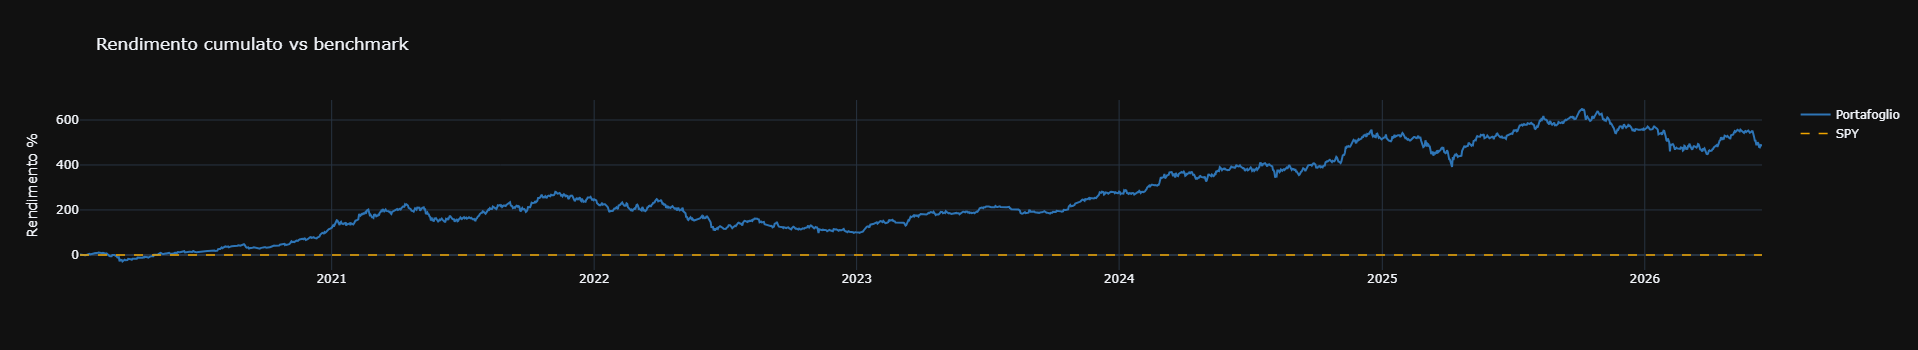

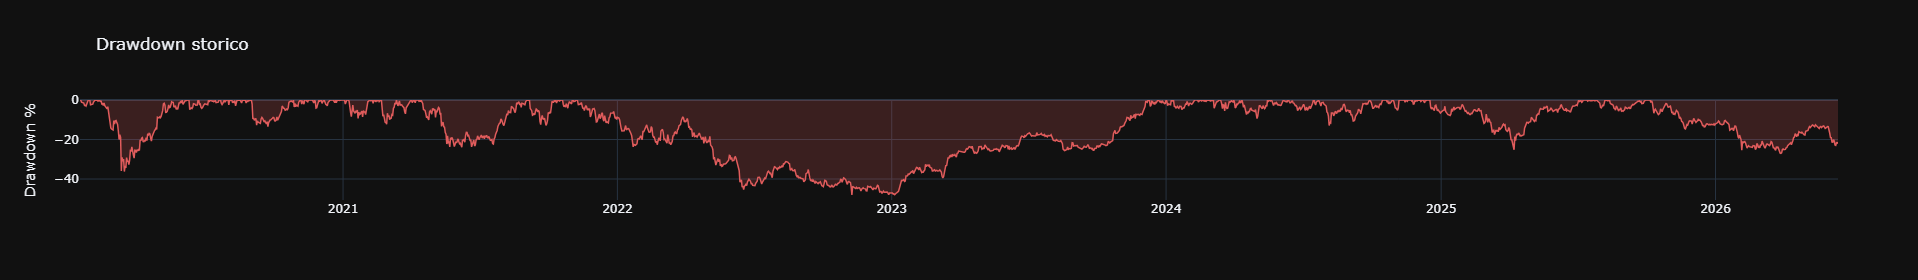

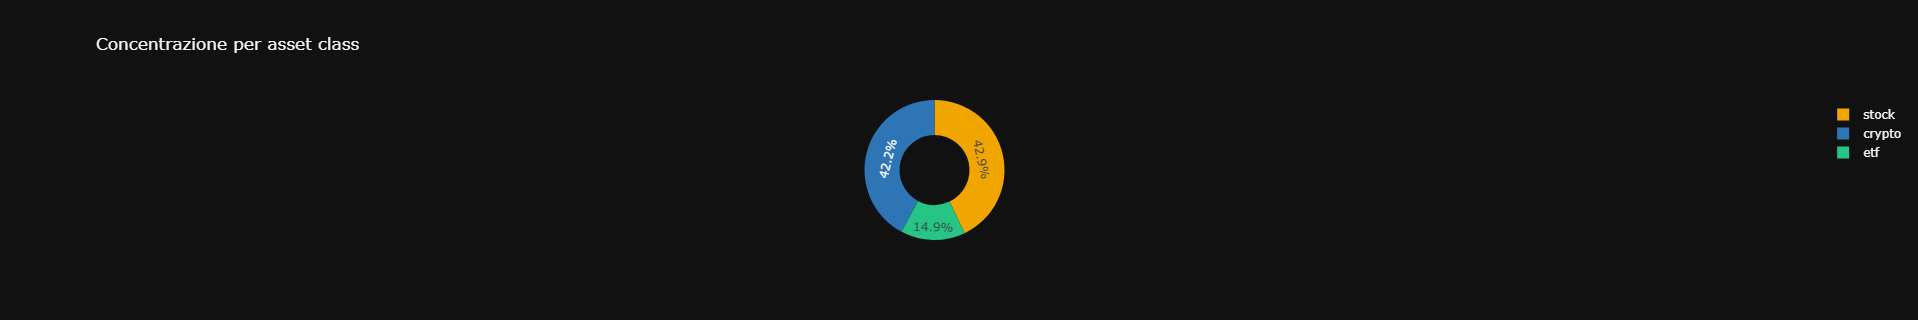

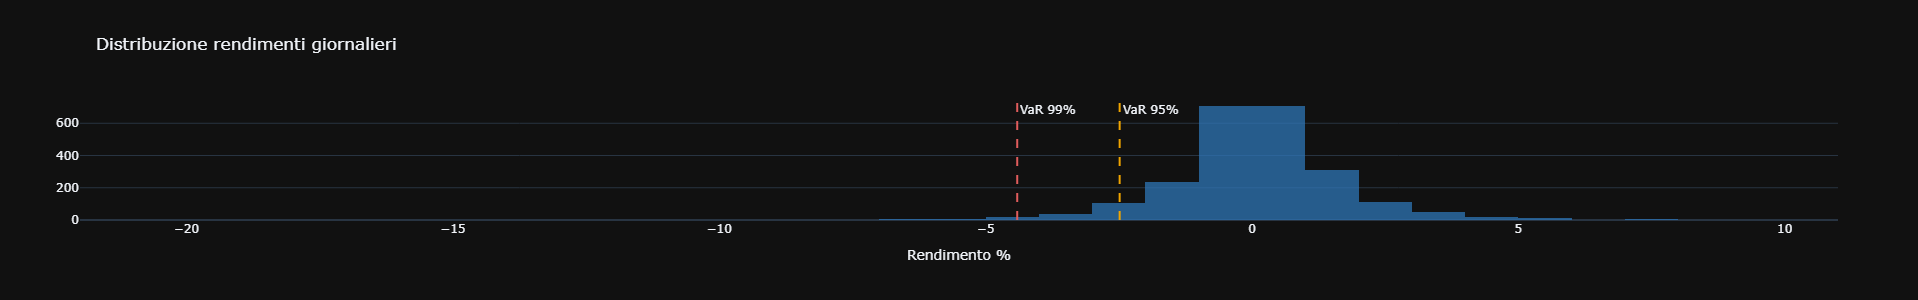

In [10]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

sr_port = results["portfolio_return"]
sr_bm   = results["benchmark_return"]

# ── Grafico 1: Rendimento cumulato ───────────────────────────
cum_port = ((1 + sr_port).cumprod() - 1) * 100
cum_bm   = ((1 + sr_bm).cumprod() - 1) * 100

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cum_port.index, y=cum_port.values,
    name="Portafoglio", line=dict(color="#2E75B6", width=2)
))
fig.add_trace(go.Scatter(
    x=cum_bm.index, y=cum_bm.values,
    name=mk["benchmark_ticker"],
    line=dict(color="#f0a500", width=1.5, dash="dash")
))
fig.update_layout(
    title="Rendimento cumulato vs benchmark",
    yaxis_title="Rendimento %",
    template="plotly_dark", height=350
)
fig.show()

# ── Grafico 2: Drawdown ──────────────────────────────────────
cum     = (1 + sr_port).cumprod()
roll_mx = cum.cummax()
dd      = (cum - roll_mx) / roll_mx * 100

fig_dd = go.Figure(go.Scatter(
    x=dd.index, y=dd.values,
    fill="tozeroy", fillcolor="rgba(224,92,92,0.2)",
    line=dict(color="#e05c5c", width=1.5),
    name="Drawdown"
))
fig_dd.update_layout(
    title="Drawdown storico",
    yaxis_title="Drawdown %",
    template="plotly_dark", height=280
)
fig_dd.show()

# ── Grafico 3: Concentrazione per asset class ────────────────
fig_pie = go.Figure(go.Pie(
    labels=list(con["by_asset_class_pct"].keys()),
    values=list(con["by_asset_class_pct"].values()),
    hole=0.5,
    marker_colors=["#2E75B6","#26c485","#f0a500","#e05c5c","#9b59b6"]
))
fig_pie.update_layout(
    title="Concentrazione per asset class",
    template="plotly_dark", height=320
)
fig_pie.show()

# ── Grafico 4: Istogramma rendimenti con VaR ─────────────────
fig_hist = go.Figure()
fig_hist.add_trace(go.Histogram(
    x=sr_port.values * 100, nbinsx=60,
    marker_color="#2E75B6", opacity=0.75,
    name="Rendimenti giornalieri"
))
fig_hist.add_vline(x=-mk["var_95"], line_color="#f0a500",
                   line_dash="dash", annotation_text="VaR 95%")
fig_hist.add_vline(x=-mk["var_99"], line_color="#e05c5c",
                   line_dash="dash", annotation_text="VaR 99%")
fig_hist.update_layout(
    title="Distribuzione rendimenti giornalieri",
    xaxis_title="Rendimento %",
    template="plotly_dark", height=300
)
fig_hist.show()


## 10 · Test `exporter.py`

Genera i 4 CSV pronti per Looker Studio e Power BI.


In [11]:
from exporter import export_all

paths = export_all(results, portfolio_name=PORTFOLIO_NAME)

print("\n🔍 VERIFICA FILE GENERATI:")
for name, path in paths.items():
    if os.path.exists(path):
        df_check = pd.read_csv(path)
        print(f"\n  📄 {name}.csv")
        print(f"     Righe:   {len(df_check)}")
        print(f"     Colonne: {df_check.columns.tolist()}")
        display(df_check.head(3))



📁 FILE ESPORTATI:
   positions       → exports\positions_test_portfolio_20260614.csv  (0.8 KB)
   returns         → exports\returns_test_portfolio_20260614.csv  (183.9 KB)
   metrics         → exports\metrics_test_portfolio_20260614.csv  (0.6 KB)
   transactions    → exports\transactions_test_portfolio_20260614.csv  (0.1 KB)

🔍 VERIFICA FILE GENERATI:

  📄 positions.csv
     Righe:   4
     Colonne: ['portfolio_name', 'export_date', 'ticker', 'asset_class', 'gics_sector', 'country', 'currency', 'pnl_status', 'qty_net', 'avg_cost', 'last_price', 'current_value', 'cost_basis', 'weight_pct', 'unrealized_pnl', 'realized_pnl', 'dividends_total', 'total_return', 'portfolio_value']


,portfolio_name,export_date,ticker,asset_class,gics_sector,country,currency,pnl_status,qty_net,avg_cost,last_price,current_value,cost_basis,weight_pct,unrealized_pnl,realized_pnl,dividends_total,total_return,portfolio_value
0,test_portfolio,20260614,BTC-USD,crypto,NaN,NaN,USD,profit,0.15,38220.000000,64421.324219,9663.20,5733.00,42.2045,3930.20,0.00,0.0,3930.20,22896.11
1,test_portfolio,20260614,AAPL,stock,Technology,United States,USD,profit,23.00,151.217391,291.130005,6695.99,3478.00,29.2451,3217.99,0.00,3.0,3220.99,22896.11
2,test_portfolio,20260614,VWRL.L,etf,NaN,NaN,GBP,profit,25.00,86.433333,136.440002,3411.00,2160.83,14.8977,1250.17,43.83,0.0,1294.00,22896.11



  📄 returns.csv
     Righe:   2340
     Colonne: ['date', 'portfolio_name', 'daily_return_pct', 'benchmark_return_pct', 'benchmark_ticker', 'cumulative_return_pct', 'benchmark_cumulative_pct', 'drawdown_pct', 'year', 'month', 'year_month']


,date,portfolio_name,daily_return_pct,benchmark_return_pct,benchmark_ticker,cumulative_return_pct,benchmark_cumulative_pct,drawdown_pct,year,month,year_month
0,2020-01-17,test_portfolio,1.501695,0.0,SPY,1.5017,0.0,0.0000,2020,1,2020-01
1,2020-01-18,test_portfolio,0.065089,0.0,SPY,1.5678,0.0,0.0000,2020,1,2020-01
2,2020-01-19,test_portfolio,-1.116434,0.0,SPY,0.4338,0.0,-1.1164,2020,1,2020-01



  📄 metrics.csv
     Righe:   1
     Colonne: ['portfolio_name', 'computed_at', 'export_date', 'portfolio_value_eur', 'cost_basis_eur', 'total_pnl_eur', 'dividends_total_eur', 'total_return_pct', 'cagr_pct', 'alpha_pct', 'benchmark_cagr_pct', 'n_years', 'sharpe_ratio', 'sortino_ratio', 'calmar_ratio', 'information_ratio', 'volatility_annual_pct', 'var_95_pct', 'var_99_pct', 'cvar_95_pct', 'cvar_99_pct', 'beta', 'correlation_benchmark', 'max_drawdown_pct', 'benchmark_ticker', 'n_trading_days', 'hhi', 'effective_n_assets', 'n_active_positions', 'risk_level']


,portfolio_name,computed_at,export_date,portfolio_value_eur,cost_basis_eur,total_pnl_eur,dividends_total_eur,total_return_pct,cagr_pct,alpha_pct,...,cvar_99_pct,beta,correlation_benchmark,max_drawdown_pct,benchmark_ticker,n_trading_days,hhi,effective_n_assets,n_active_positions,risk_level
0,test_portfolio,2026-06-14 12:00:05,20260614,22896.11,13479.43,9525.11,3.0,490.6576,21.0785,NaN,...,6.4947,NaN,NaN,-48.0811,SPY,2340,0.3045,3.28,4,high



  📄 transactions.csv
     Righe:   0
     Colonne: ['portfolio_name', 'export_date', 'ticker', 'tx_date', 'tx_type', 'quantity', 'price', 'currency', 'fees', 'notes', 'current_value_tx', 'tx_cost', 'year', 'month', 'year_month']


,portfolio_name,export_date,ticker,tx_date,tx_type,quantity,price,currency,fees,notes,current_value_tx,tx_cost,year,month,year_month


## 11 · Cleanup (opzionale)

Esegui questa cella per cancellare i dati di test dal database e ricominciare da capo.


In [12]:
# ⚠️ ATTENZIONE: cancella tutti i dati del portfolio di test

risposta = input("Sei sicuro di voler cancellare i dati di test? (scrivi 'si' per confermare): ")

if risposta.strip().lower() == "si":
    with engine.begin() as conn:
        conn.execute(text("DELETE FROM portfolios WHERE name = :name"),
                     {"name": PORTFOLIO_NAME})
    print(f"✅ Dati del portfolio '{PORTFOLIO_NAME}' rimossi")
    print("   (assets e market_prices rimangono — sono condivisi tra portafogli)")
else:
    print("❌ Operazione annullata")


Sei sicuro di voler cancellare i dati di test? (scrivi 'si' per confermare):  si


✅ Dati del portfolio 'Test Portfolio' rimossi
   (assets e market_prices rimangono — sono condivisi tra portafogli)


## ✅ Riepilogo test

| Modulo | Status | Note |
|--------|--------|------|
| `validator.py` | ✅ | Normalizzazione date, fix crypto ticker, fix dividend |
| `fetcher.py` | ✅ | Download yfinance, INSERT IGNORE, gestione ISIN |
| `risk_engine.py` | ✅ | VaR, Sharpe, Sortino, beta, HHI, concentrazione |
| `exporter.py` | ✅ | 4 CSV per Looker Studio e Power BI |

### Prossimi passi
1. Sostituisci `data/test_portfolio.csv` con i tuoi dati reali del **Wealth-app**
2. Avvia la Streamlit app: `streamlit run app.py`
3. Importa i CSV da `exports/` in **Google Looker Studio**
4. Importa i CSV in **Power BI**
